<a href="https://colab.research.google.com/github/Joacco11/TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X – Parte 2: Predicción de Cancelación (Churn)

##🛠️ Preparación de los Datos

###Extracción del Archivo Tratado

In [249]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
url = 'https://raw.githubusercontent.com/Joacco11/TelecomX_Latam-Part-1/refs/heads/main/telecomx_clean.csv'
df = pd.read_csv(url, index_col="id_cliente")
df.head()

,churn,genero,adulto_mayor,pareja,dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,seguridad_en_linea,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_electronica,metodo_pago,cargo_mensual,cargo_total,Cuentas_Diarias
id_cliente,,,,,,,,,,,,,,,,,,,,,
0002-ORFBO,No,Female,False,True,True,9,True,No,DSL,No,...,No,Yes,Yes,No,One year,True,Mailed check,65.6,593.30,2.19
0003-MKNFE,No,Male,False,False,False,9,True,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,False,Mailed check,59.9,542.40,2.00
0004-TLHLJ,Yes,Male,False,False,False,4,True,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,True,Electronic check,73.9,280.85,2.46
0011-IGKFF,Yes,Male,True,True,False,13,True,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,True,Electronic check,98.0,1237.85,3.27
0013-EXCHZ,Yes,Female,True,True,False,3,True,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,True,Mailed check,83.9,267.40,2.80


>En el proyecto anterior no eliminé los valores nulos en **churn** y **cargo_total** porque lo que buscaba era representar la realidad del negocio, pero en el caso del desarrollo del modelo predictivo, realizaré la limpieza de estos campos ya que no los necesito

In [250]:
# 1. Eliminar filas con "No se sabe" en churn
df = df[df['churn'] != "No se sabe"]

# 2. Imputar valores nulos en cargo_total con la media
df['cargo_total'] = df['cargo_total'].fillna(df['cargo_total'].mean())

# 3. Verificar
print(df['churn'].value_counts())
print("Nulos en cargo_total:", df['cargo_total'].isna().sum())

churn
No     5174
Yes    1869
Name: count, dtype: int64
Nulos en cargo_total: 0



###Eliminación de Columnas Irrelevantes

>Id_cliente está como index. Cuentas_diarias no la  al ser una columna de caracter artificial.


In [251]:
df = df.drop(columns=['Cuentas_Diarias'])
df.shape

(7043, 20)

###Encoding

####Separación de target y variables

In [252]:
x = df.drop(columns=['churn'])
y = df['churn']

x.dtypes

,0
genero,object
adulto_mayor,bool
pareja,bool
dependientes,bool
antiguedad_meses,int64
servicio_telefonico,bool
lineas_multiples,object
servicio_internet,object
seguridad_en_linea,object
respaldo_en_linea,object


In [253]:
cat = x.select_dtypes(include=['object']).columns
num = x.select_dtypes(include=['int', 'float']).columns
bin = x.select_dtypes(include=['bool']).columns

print("Categóricas:", cat.tolist())
print("Numéricas:", num.tolist())
print("Booleanas:", bin.tolist())

Categóricas: ['genero', 'lineas_multiples', 'servicio_internet', 'seguridad_en_linea', 'respaldo_en_linea', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'metodo_pago']
Numéricas: ['antiguedad_meses', 'cargo_mensual', 'cargo_total']
Booleanas: ['adulto_mayor', 'pareja', 'dependientes', 'servicio_telefonico', 'facturacion_electronica']


####Tratamiento de categóricas


In [254]:
one_hot =  make_column_transformer((OneHotEncoder(drop='first'), cat), remainder='passthrough',
                                   sparse_threshold=0,force_int_remainder_cols=False)
x_enc = one_hot.fit_transform(x)
ohe_cols = one_hot.named_transformers_['onehotencoder'].get_feature_names_out(cat)
# Combinar nombres de OHE + resto de columnas
all_cols = list(ohe_cols) + [col for col in x.columns if col not in cat]

# Convertir a DataFrame
x = pd.DataFrame(x_enc, columns=all_cols, index=x.index)

print(x.shape)
print(all_cols)

(7043, 30)
['genero_Male', 'lineas_multiples_No phone service', 'lineas_multiples_Yes', 'servicio_internet_Fiber optic', 'servicio_internet_No', 'seguridad_en_linea_No internet service', 'seguridad_en_linea_Yes', 'respaldo_en_linea_No internet service', 'respaldo_en_linea_Yes', 'proteccion_dispositivo_No internet service', 'proteccion_dispositivo_Yes', 'soporte_tecnico_No internet service', 'soporte_tecnico_Yes', 'streaming_tv_No internet service', 'streaming_tv_Yes', 'streaming_peliculas_No internet service', 'streaming_peliculas_Yes', 'tipo_contrato_One year', 'tipo_contrato_Two year', 'metodo_pago_Credit card (automatic)', 'metodo_pago_Electronic check', 'metodo_pago_Mailed check', 'adulto_mayor', 'pareja', 'dependientes', 'antiguedad_meses', 'servicio_telefonico', 'facturacion_electronica', 'cargo_mensual', 'cargo_total']


####Tratamiento del target


In [255]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y

array([0, 0, 1, ..., 0, 0, 0])

###Verificación de la Proporción de Cancelación (Churn)

In [256]:
# Conteo de cada clase
unique, counts = np.unique(y, return_counts=True)

# Proporción de cada clase
proporcion = counts / len(y)

for u, c, p in zip(unique, counts, proporcion):
    print(f"Clase {u}: {c} clientes ({p:.2%})")


Clase 0: 5174 clientes (73.46%)
Clase 1: 1869 clientes (26.54%)


###Balanceo de Clases

In [257]:
# Definir oversampler
oversampler = RandomOverSampler(random_state=42)

# Aplicar oversampling sobre X e y
X_res, y_res = oversampler.fit_resample(x, y)

print("Tamaño original:", len(y))
print("Tamaño balanceado:", len(y_res))

# Ver distribución después del oversampling
print(pd.Series(y_res).value_counts())


Tamaño original: 7043
Tamaño balanceado: 10348
0    5174
1    5174
Name: count, dtype: int64


In [258]:
x = X_res
y = y_res
df_train = pd.DataFrame.from_records(x, columns=all_cols)
df_train['churn'] = y
df_train.head()

/tmp/ipython-input-2020816562.py:3: FutureWarning: Passing a DataFrame to DataFrame.from_records is deprecated. Use set_index and/or drop to modify the DataFrame instead.
  df_train = pd.DataFrame.from_records(x, columns=all_cols)


,genero_Male,lineas_multiples_No phone service,lineas_multiples_Yes,servicio_internet_Fiber optic,servicio_internet_No,seguridad_en_linea_No internet service,seguridad_en_linea_Yes,respaldo_en_linea_No internet service,respaldo_en_linea_Yes,proteccion_dispositivo_No internet service,...,metodo_pago_Mailed check,adulto_mayor,pareja,dependientes,antiguedad_meses,servicio_telefonico,facturacion_electronica,cargo_mensual,cargo_total,churn
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,False,True,True,9,True,True,65.6,593.3,0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,False,False,False,9,True,False,59.9,542.4,0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,False,False,False,4,True,True,73.9,280.85,1
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,True,True,False,13,True,True,98.0,1237.85,1
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,True,True,False,3,True,True,83.9,267.4,1


##🎯 Correlación y Selección de Variables

####Análisis de Correlación

In [259]:
corr = df_train.corr()
corr['churn'].sort_values(ascending=False)

,churn
churn,1.000000
servicio_internet_Fiber optic,0.336075
metodo_pago_Electronic check,0.330166
cargo_mensual,0.220256
facturacion_electronica,0.219138
adulto_mayor,0.157474
streaming_tv_Yes,0.070800
streaming_peliculas_Yes,0.069518
lineas_multiples_Yes,0.036134
servicio_telefonico,0.006530


####Análisis Dirigido

>Me pareció lo más óptimo tener dos datas. df (Datos limpios sin aplicar el oversampling y one hot encoder) para realizar el análisis en esta sección. Y df_train (Con el oversampling y one hot encoder aplicado) para el uso del modelo XGBoost

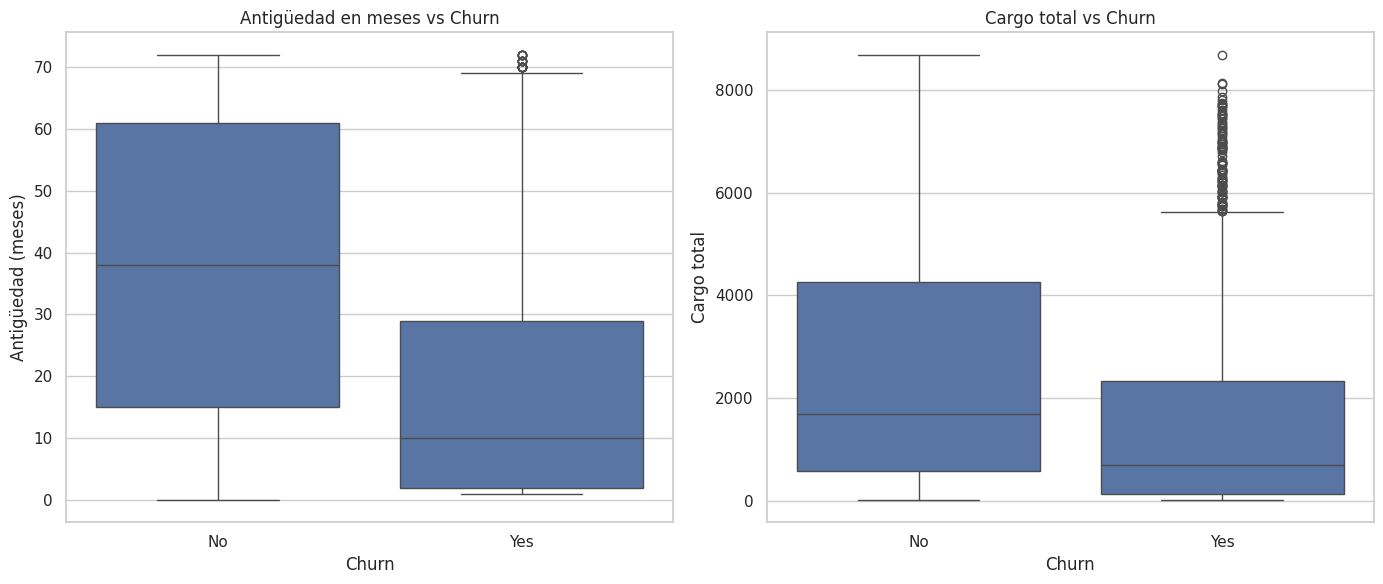

In [260]:
# Ajustar estilo
sns.set(style="whitegrid")

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Boxplot 1: Antigüedad en meses vs churn ---
sns.boxplot(x='churn', y='antiguedad_meses', data=df, ax=axes[0])
axes[0].set_title("Antigüedad en meses vs Churn", fontsize=12)
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Antigüedad (meses)")

# --- Boxplot 2: Cargo total vs churn ---
sns.boxplot(x='churn', y='cargo_total', data=df, ax=axes[1])
axes[1].set_title("Cargo total vs Churn", fontsize=12)
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Cargo total")

plt.tight_layout()
plt.show()

>💡 Interpretación práctica para tu informe:

1. Tiempo de relación con la empresa es un factor más determinante que el gasto acumulado.

2. Gasto total también aporta información, pero es menos decisivo.

3. Ambos gráficos complementan el análisis de correlación: muestran la magnitud real de las diferencias entre grupos.
4. A demás se visualizan muchos valores atípicos en la columna [gasto_total]. Pero para el modelo XGBoost no afecta mucho

##🤖 Modelado Predictivo

####Separación de Datos(Train-Test)


In [261]:
X_train, X_test, y_train, y_test = train_test_split(x, y,stratify=y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7243, 30), (3105, 30), (7243,), (3105,))

####Modelo BaseLine

In [262]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

0.4998389694041868


####Random Forest

In [263]:
modelo_arbol = DecisionTreeClassifier()
modelo_arbol.fit(X_train, y_train)
modelo_arbol.score(X_test, y_test)

0.8615136876006442

In [264]:
#Modifico la profundidad del arbol solo para que sea más legible. La Max taza de acierto es el anterior
modelo_arbol = DecisionTreeClassifier(max_depth=5)
modelo_arbol.fit(X_train, y_train)
modelo_arbol.score(X_test, y_test)

0.7600644122383253

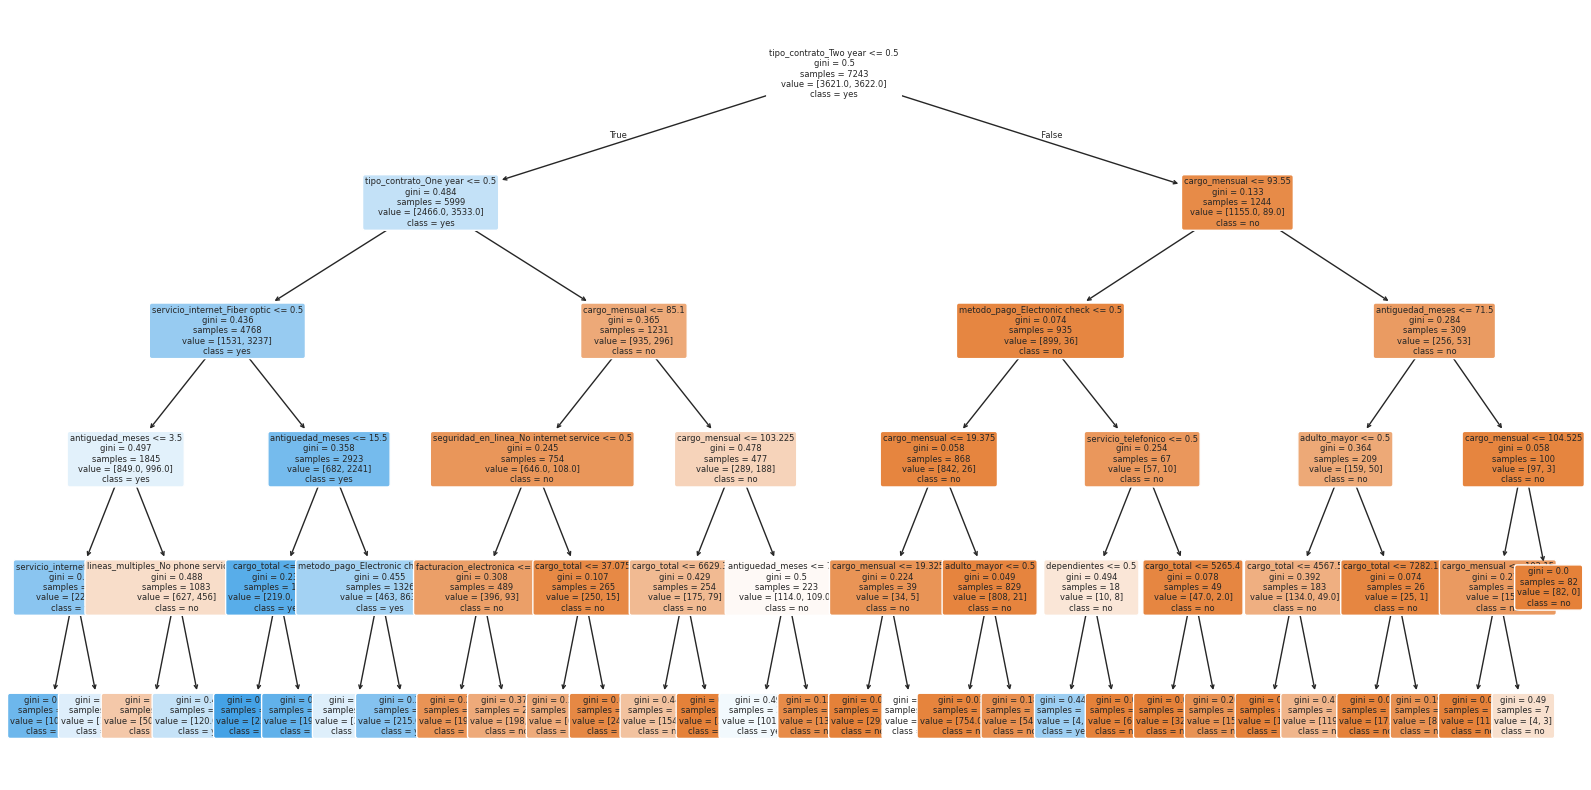

In [265]:
columnas = X_train.columns.to_list()
plt.figure(figsize=(20,10))  # 80,25 es muy grande para visualizar
plot_tree(modelo_arbol,
          feature_names=columnas,
          filled=True,
          class_names=['no','yes'],
          rounded=True,
          fontsize=6)
plt.show()

####KNN (Kvecinos)

#####Normalización

In [266]:
normalizacion = MinMaxScaler()
X_train_norm = normalizacion.fit_transform(X_train)
X_test_norm = normalizacion.transform(X_test)

((10348, 30), (10348,))

##📋 Interpretación y Conclusiones